# ARC mistake iteration analyzer

`evaluate_trained_model.py` と `visualize_arc1withgen_aug_1000.ipynb` の流れを合わせて、特定の ARC 問題について推論 loop ごとの出力変化と各セルの確信度を可視化します。

In [2]:
from pathlib import Path
import json
import math
import random

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from matplotlib.colors import BoundaryNorm, ListedColormap

from models.layers import (
    apply_rotary_pos_emb,
    apply_rotary_pos_emb_2d,
    apply_rotary_pos_emb_3d,
    apply_rotary_pos_emb_4d,
    apply_rotary_pos_emb_one,
)
from evaluate_trained_model import (
    apply_eval_overrides,
    load_config_from_checkpoint,
    _checkpoint_step,
    _resolve_checkpoint_path,
)
from logger import global_logger
from models.losses import IGNORE_LABEL_ID
from pretrain import create_dataloader, init_train_state, _get_loop_config, _load_model_state
from puzzle_dataset import PuzzleDatasetConfig
from puzzle_full_dataset import PuzzleFullDataset

plt.rcParams["figure.dpi"] = 120

## 設定

`CHECKPOINT` と対象問題を変更してください。`SPLIT="test"` の場合は、test example に保存されている train context と query を使って評価時と同じ full-context sample を作ります。

In [3]:
# ここを変更してください
CHECKPOINT = "checkpoints/URM-arcagi1-full-gen-2"  # checkpoint file or directory
DATASET_DIR = None  # None なら checkpoint の config.data_path を使う。例: Path("data/arc1withgen-aug-1000")

SPLIT = "test"       # "train" or "test"
GROUP_ID = 6          # 0-based group id
PUZZLE_ID = 0         # group 内 local puzzle id。PUZZLE_ID_MODE="absolute" なら split 全体の puzzle index
PUZZLE_ID_MODE = "local"  # "local", "absolute", or "auto"
EXAMPLE_ID = 0        # puzzle 内 local example id。EXAMPLE_ID_MODE="absolute" なら split 全体の example index
EXAMPLE_ID_MODE = "local"  # "local", "absolute", "auto", or "random"
RANDOM_SEED = 0       # EXAMPLE_ID_MODE="random" のときだけ使う

BATCH_SIZE = 1
LOOPS_TO_RUN = 8
LOOPS_TO_SHOW = list(range(1, 8))
HIDDEN_DIFF_THRESHOLD = None

# Attention Map の表示範囲。(-1, -1) なら全表示、(start, end) なら inclusive に表示
ATTENTION_LOOP_RANGE = (1, 1)
ATTENTION_LAYER_RANGE = (-1, -1)

# train split で full-context sample を作るとき、対象 example 以外に同じ puzzle から何個 context を入れるか
TRAIN_CONTEXT_COUNT = 3

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEVICE)

device: cuda


In [4]:
ARC_TOKEN_PAD = 0
ARC_TOKEN_EOS = 1
ARC_TOKEN_COLOR_OFFSET = 2
ARC_NUM_TOKENS = 12

ARC_TOKEN_COLORS = [
    "#2D257F",  # token 0: PAD
    "#E6E6E6",  # token 1: <eos>
    "#000000",  # token 2: ARC color 0
    "#0074D9",  # token 3: ARC color 1 blue
    "#FF4136",  # token 4: ARC color 2 red
    "#2ECC40",  # token 5: ARC color 3 green
    "#FFDC00",  # token 6: ARC color 4 yellow
    "#AAAAAA",  # token 7: ARC color 5 gray
    "#F012BE",  # token 8: ARC color 6 magenta
    "#FF851B",  # token 9: ARC color 7 orange
    "#7FDBFF",  # token 10: ARC color 8 cyan
    "#870C25",  # token 11: ARC color 9 dark red
]
ARC_CMAP = ListedColormap(ARC_TOKEN_COLORS)
ARC_NORM = BoundaryNorm(np.arange(-0.5, ARC_NUM_TOKENS + 0.5, 1.0), ARC_CMAP.N)


def decode_arc_canvas(tokens, shape):
    canvas = np.asarray(tokens, dtype=np.uint8).reshape(tuple(int(x) for x in shape))
    nonzero_rows = np.flatnonzero(np.any(canvas != ARC_TOKEN_PAD, axis=1))
    nonzero_cols = np.flatnonzero(np.any(canvas != ARC_TOKEN_PAD, axis=0))
    if nonzero_rows.size == 0 or nonzero_cols.size == 0:
        return np.zeros((1, 1), dtype=np.uint8)
    active = canvas[: int(nonzero_rows[-1]) + 1, : int(nonzero_cols[-1]) + 1]
    eos_rows = np.flatnonzero(np.any(active == ARC_TOKEN_EOS, axis=1) & ~np.any(active >= ARC_TOKEN_COLOR_OFFSET, axis=1))
    eos_cols = np.flatnonzero(np.any(active == ARC_TOKEN_EOS, axis=0) & ~np.any(active >= ARC_TOKEN_COLOR_OFFSET, axis=0))
    grid_h = int(eos_rows[0]) if eos_rows.size else active.shape[0]
    grid_w = int(eos_cols[0]) if eos_cols.size else active.shape[1]
    cropped = active[:grid_h, :grid_w]
    if cropped.size == 0:
        return np.zeros((1, 1), dtype=np.uint8)
    return cropped.astype(np.uint8)


def render_grid(ax, grid, title, wrong_mask=None, changed_mask=None):
    grid = np.asarray(grid)
    ax.imshow(grid, cmap=ARC_CMAP, norm=ARC_NORM, interpolation="nearest")
    ax.set_title(f"{title}\n{grid.shape[0]}x{grid.shape[1]}", fontsize=10)
    ax.set_xticks(np.arange(-0.5, grid.shape[1], 1), minor=True)
    ax.set_yticks(np.arange(-0.5, grid.shape[0], 1), minor=True)
    ax.grid(which="minor", color="#222222", linewidth=0.45)
    ax.tick_params(which="both", bottom=False, left=False, labelbottom=False, labelleft=False)
    ax.set_aspect("equal")
    for spine in ax.spines.values():
        spine.set_color("#666666")
        spine.set_linewidth(1.0)
    if wrong_mask is not None:
        ys, xs = np.where(wrong_mask)
        ax.scatter(xs, ys, marker="x", s=80, linewidths=1.6, color="white")
        ax.scatter(xs, ys, marker="x", s=45, linewidths=1.2, color="#D62728")
    if changed_mask is not None:
        ys, xs = np.where(changed_mask)
        ax.scatter(xs, ys, marker="o", s=55, facecolors="none", edgecolors="#00FFFF", linewidths=1.5)


def render_confidence(ax, confidence, title):
    confidence = np.asarray(confidence, dtype=float)
    image = ax.imshow(confidence, cmap="viridis", vmin=0.0, vmax=1.0, interpolation="nearest")
    ax.set_title(title, fontsize=10)
    ax.set_xticks(np.arange(-0.5, confidence.shape[1], 1), minor=True)
    ax.set_yticks(np.arange(-0.5, confidence.shape[0], 1), minor=True)
    ax.grid(which="minor", color="white", linewidth=0.35, alpha=0.45)
    ax.tick_params(which="both", bottom=False, left=False, labelbottom=False, labelleft=False)
    ax.set_aspect("equal")
    return image

In [5]:
def load_split_arrays(dataset_dir: Path, split: str):
    split_dir = dataset_dir / split
    with (split_dir / "dataset.json").open() as f:
        metadata = json.load(f)
    data = {
        "split": split,
        "metadata": metadata,
        "inputs": np.load(split_dir / "all__inputs.npy", mmap_mode="r"),
        "labels": np.load(split_dir / "all__labels.npy", mmap_mode="r"),
        "seq_offsets": np.load(split_dir / "all__seq_offsets.npy"),
        "label_seq_offsets": np.load(split_dir / "all__label_seq_offsets.npy"),
        "seq_shapes": np.load(split_dir / "all__seq_shapes.npy"),
        "label_seq_shapes": np.load(split_dir / "all__label_seq_shapes.npy"),
        "puzzle_indices": np.load(split_dir / "all__puzzle_indices.npy"),
        "group_indices": np.load(split_dir / "all__group_indices.npy"),
        "puzzle_identifiers": np.load(split_dir / "all__puzzle_identifiers.npy"),
    }
    examples_path = split_dir / "all__examples.npy"
    example_shapes_path = split_dir / "all__example_shapes.npy"
    if examples_path.exists() and example_shapes_path.exists():
        data["examples"] = np.load(examples_path, allow_pickle=True)
        data["example_shapes"] = np.load(example_shapes_path, allow_pickle=True)
    return data


def resolve_puzzle_index(split_data, group_id, puzzle_id, mode="local"):
    group_indices = split_data["group_indices"]
    if not (0 <= group_id < len(group_indices) - 1):
        raise IndexError(f"GROUP_ID={group_id} is out of range [0, {len(group_indices) - 2}]")
    group_start = int(group_indices[group_id])
    group_end = int(group_indices[group_id + 1])
    group_size = group_end - group_start
    if mode == "local":
        if not (0 <= puzzle_id < group_size):
            raise IndexError(f"local PUZZLE_ID={puzzle_id} is out of range [0, {group_size - 1}] for group {group_id}")
        return group_start + int(puzzle_id)
    if mode == "absolute":
        if not (group_start <= puzzle_id < group_end):
            raise IndexError(f"absolute PUZZLE_ID={puzzle_id} is not in group {group_id}; valid [{group_start}, {group_end - 1}]")
        return int(puzzle_id)
    if mode == "auto":
        if group_start <= puzzle_id < group_end:
            return int(puzzle_id)
        if 0 <= puzzle_id < group_size:
            return group_start + int(puzzle_id)
    raise ValueError('PUZZLE_ID_MODE must be "local", "absolute", or "auto"')


def resolve_example_index(split_data, puzzle_index, example_id, mode="local", seed=None):
    start = int(split_data["puzzle_indices"][puzzle_index])
    end = int(split_data["puzzle_indices"][puzzle_index + 1])
    if start >= end:
        raise ValueError(f"puzzle_index={puzzle_index} has no examples")
    if mode == "random":
        return random.Random(seed).randrange(start, end)
    if mode == "local":
        if not (0 <= example_id < end - start):
            raise IndexError(f"local EXAMPLE_ID={example_id} is out of range [0, {end - start - 1}]")
        return start + int(example_id)
    if mode == "absolute":
        if not (start <= example_id < end):
            raise IndexError(f"absolute EXAMPLE_ID={example_id} is not in puzzle; valid [{start}, {end - 1}]")
        return int(example_id)
    if mode == "auto":
        if start <= example_id < end:
            return int(example_id)
        if 0 <= example_id < end - start:
            return start + int(example_id)
    raise ValueError('EXAMPLE_ID_MODE must be "local", "absolute", "auto", or "random"')


def identifier_name(dataset_dir: Path, split_data, puzzle_index):
    with (dataset_dir / "identifiers.json").open() as f:
        identifiers = json.load(f)
    ident = int(split_data["puzzle_identifiers"][puzzle_index])
    return identifiers[ident] if 0 <= ident < len(identifiers) else f"<unknown:{ident}>"


def load_example_pair(split_data, example_index):
    in_start = int(split_data["seq_offsets"][example_index])
    in_end = int(split_data["seq_offsets"][example_index + 1])
    label_start = int(split_data["label_seq_offsets"][example_index])
    label_end = int(split_data["label_seq_offsets"][example_index + 1])
    input_shape = split_data["seq_shapes"][example_index]
    output_shape = split_data["label_seq_shapes"][example_index]
    input_grid = decode_arc_canvas(split_data["inputs"][in_start:in_end], input_shape)
    output_grid = decode_arc_canvas(split_data["labels"][label_start:label_end], output_shape)
    return input_grid, output_grid


def load_context_pairs_if_available(split_data, example_index):
    if "examples" not in split_data:
        return []
    context = split_data["examples"][example_index]
    context_shapes = split_data["example_shapes"][example_index]
    pairs = []
    for i in range(len(context)):
        inp = decode_arc_canvas(context[i][0], context_shapes[i][0])
        out = decode_arc_canvas(context[i][1], context_shapes[i][1])
        pairs.append((inp, out))
    return pairs

In [6]:
resolved_checkpoint = _resolve_checkpoint_path(CHECKPOINT)
if resolved_checkpoint is None:
    raise FileNotFoundError(f"Could not resolve checkpoint path from: {CHECKPOINT}")
checkpoint_path = Path(resolved_checkpoint)

config = load_config_from_checkpoint(str(checkpoint_path))
apply_eval_overrides(
    config,
    batch_size=BATCH_SIZE,
    loops=None,
    hidden_diff_threshold=HIDDEN_DIFF_THRESHOLD,
)
config.checkpoint_path = str(checkpoint_path.parent)
dataset_dir = Path(config.data_path if DATASET_DIR is None else DATASET_DIR)
config.data_path = str(dataset_dir)
config.torch_compile = False  # iteration tracing uses irregular single samples; avoid Dynamo shape-guard failures

print("checkpoint:", checkpoint_path)
print("dataset:", dataset_dir)
print("mask_full_training:", config.mask_full_training)
print("checkpoint_loops:", getattr(config.arch, "loops", None))
print("loops_to_run:", LOOPS_TO_RUN)
print("torch_compile:", config.torch_compile)

checkpoint: checkpoints/URM-arcagi1-full-gen-2/step_23820.pt
dataset: data/arc1withgen-aug-1000
mask_full_training: True
checkpoint_loops: 32
loops_to_run: 8
torch_compile: False


split: test
group_id: 6  puzzle range: [6000, 6999]  group size: 1000
puzzle_index: 6000  local puzzle id: 0
puzzle identifier: 94414823
example_index: 8000  local example id: 0 / 0


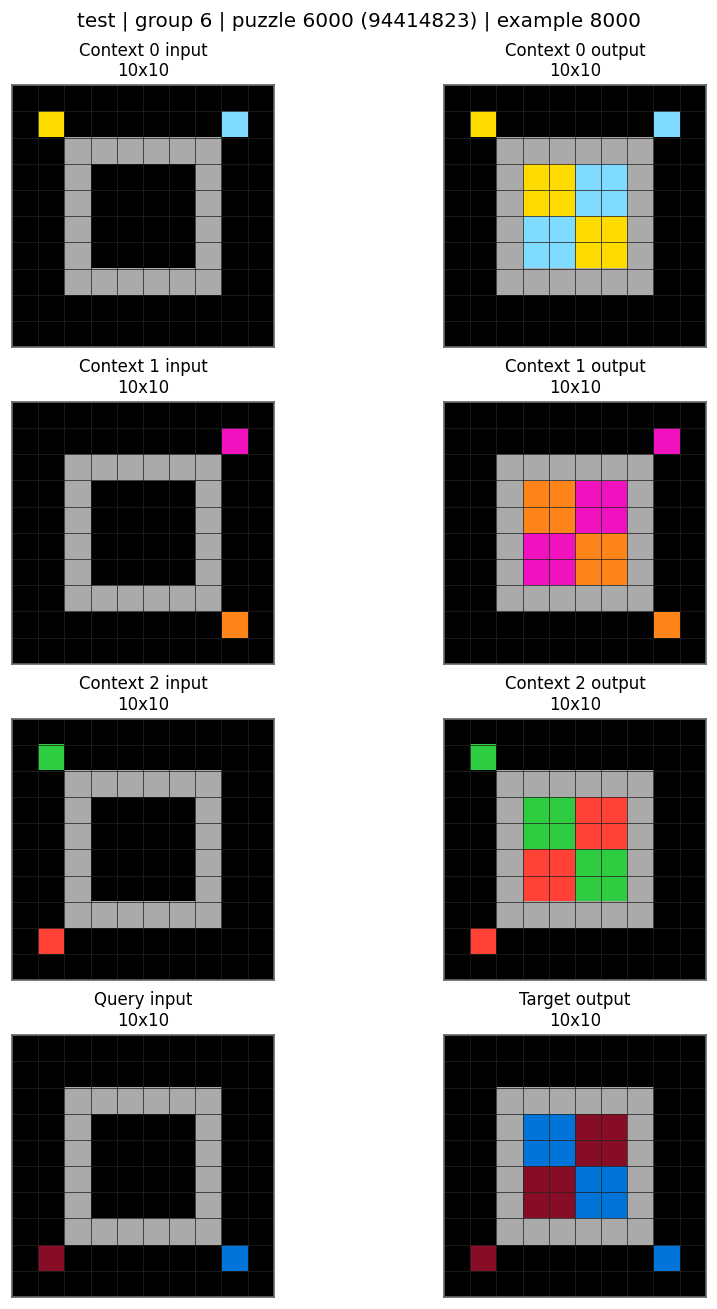

In [7]:
split_data = load_split_arrays(dataset_dir, SPLIT)
puzzle_index = resolve_puzzle_index(split_data, GROUP_ID, PUZZLE_ID, PUZZLE_ID_MODE)
example_index = resolve_example_index(split_data, puzzle_index, EXAMPLE_ID, EXAMPLE_ID_MODE, RANDOM_SEED)

group_start = int(split_data["group_indices"][GROUP_ID])
group_end = int(split_data["group_indices"][GROUP_ID + 1])
puzzle_start = int(split_data["puzzle_indices"][puzzle_index])
puzzle_end = int(split_data["puzzle_indices"][puzzle_index + 1])
name = identifier_name(dataset_dir, split_data, puzzle_index)

print(f"split: {SPLIT}")
print(f"group_id: {GROUP_ID}  puzzle range: [{group_start}, {group_end - 1}]  group size: {group_end - group_start}")
print(f"puzzle_index: {puzzle_index}  local puzzle id: {puzzle_index - group_start}")
print(f"puzzle identifier: {name}")
print(f"example_index: {example_index}  local example id: {example_index - puzzle_start} / {puzzle_end - puzzle_start - 1}")

context_pairs = load_context_pairs_if_available(split_data, example_index)
target_input, target_output = load_example_pair(split_data, example_index)

rows = len(context_pairs) + 1
fig, axes = plt.subplots(rows, 2, figsize=(7.2, max(3.0, 2.7 * rows)), squeeze=False, constrained_layout=True)
for row, (inp, out) in enumerate(context_pairs):
    render_grid(axes[row, 0], inp, f"Context {row} input")
    render_grid(axes[row, 1], out, f"Context {row} output")
render_grid(axes[-1, 0], target_input, "Query input")
render_grid(axes[-1, 1], target_output, "Target output")
fig.suptitle(f"{SPLIT} | group {GROUP_ID} | puzzle {puzzle_index} ({name}) | example {example_index}", fontsize=12)
plt.show()

In [ ]:
def make_full_dataset(config, split):
    ds = PuzzleFullDataset(
        PuzzleDatasetConfig(
            seed=config.seed,
            dataset_path=config.data_path,
            global_batch_size=1,
            test_set_mode=(split == "test"),
            epochs_per_iter=1,
            grad_accum_steps=1,
            rank=0,
            num_replicas=1,
            data_fraction=1.0,
            examples_per_puzzle=config.examples_per_puzzle,
            online_aug=None,
            masked_input=config.masked_input,
            arc_output_mask=None,
            full_min_pairs=config.full_min_pairs,
            full_max_pairs=config.full_max_pairs,
            full_answer_initial_mode=config.full_answer_initial_mode,
            full_answer_initial_black_token_id=config.full_answer_initial_black_token_id,
            full_answer_initial_gamma_min=config.full_answer_initial_gamma_min,
            full_answer_initial_gamma_max=config.full_answer_initial_gamma_max,
            # full_answer_initial_noise_token_min=config.full_answer_initial_noise_token_min,
            # full_answer_initial_noise_token_max=config.full_answer_initial_noise_token_max,
            answer_only_labels=bool(getattr(config.arch, "answer_only", False)),
        ),
        split=split,
    )
    ds._lazy_load_dataset()
    return ds


def build_single_full_batch(ds, split_data, puzzle_index, example_index):
    dataset = ds._data["all"]
    if ds.split == "test":
        sample = ds._build_test_sample(dataset, int(example_index))
    else:
        start = int(split_data["puzzle_indices"][puzzle_index])
        end = int(split_data["puzzle_indices"][puzzle_index + 1])
        rng = np.random.default_rng(RANDOM_SEED)
        candidates = [i for i in range(start, end) if i != example_index]
        if len(candidates) < TRAIN_CONTEXT_COUNT:
            chosen_context = candidates
        else:
            chosen_context = rng.choice(candidates, size=TRAIN_CONTEXT_COUNT, replace=False).tolist()
        selected = np.array(chosen_context + [int(example_index)], dtype=np.int64)
        sample = ds._build_full_sample(dataset, selected, rng, target_pair_index=len(selected) - 1)

    puzzle_identifier = np.array([int(split_data["puzzle_identifiers"][puzzle_index])], dtype=np.int64)
    return ds._collate_built_samples([sample], puzzle_identifier)


full_ds = make_full_dataset(config, SPLIT)
batch_cpu = build_single_full_batch(full_ds, split_data, puzzle_index, example_index)
print({k: tuple(v.shape) for k, v in batch_cpu.items()})

AttributeError: 'PretrainConfig' object has no attribute 'full_answer_initial_noise_token_min'

In [ ]:
if DEVICE != "cuda":
    raise RuntimeError("この notebook は evaluate_trained_model.py と同じく CUDA 前提です。CUDA 環境で実行してください。")

torch.random.manual_seed(config.seed)
train_loader, train_metadata = create_dataloader(
    config,
    "train",
    test_set_mode=False,
    epochs_per_iter=1,
    global_batch_size=1,
    rank=0,
    world_size=1,
)
train_state = init_train_state(config, train_metadata, rank=0, world_size=1)
checkpoint = torch.load(checkpoint_path, map_location="cuda")
if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
    state_dict = checkpoint["model_state_dict"]
    step = checkpoint.get("step")
else:
    state_dict = checkpoint
    step = None
if not config.torch_compile and any(k.startswith("_orig_mod.") for k in state_dict):
    state_dict = {k.removeprefix("_orig_mod."): v for k, v in state_dict.items()}
    print("stripped _orig_mod. prefix from compiled checkpoint weights")
_load_model_state(train_state, config, state_dict, rank=0)
train_state.step = int(step) if step is not None else _checkpoint_step(checkpoint_path)
train_state.carry = None
train_state.accum_carries = None
train_state.accum_metrics = None
train_state.model.eval()

loop_config = _get_loop_config(train_state.model)
if loop_config is not None and HIDDEN_DIFF_THRESHOLD is not None:
    loop_config.norm_diff_min = HIDDEN_DIFF_THRESHOLD
    loop_config.norm_diff_max = HIDDEN_DIFF_THRESHOLD

del train_loader
print("model loaded")
print("model_checkpoint_loops:", getattr(loop_config, "loops", None))

Dataset train has 960 groups.
Training split uses PuzzleFullDataset with 3-8 pairs per sample.
Created dataloader for split 'train'.
torch.compile disabled
stripped _orig_mod. prefix from compiled checkpoint weights
model loaded
model_checkpoint_loops: 32


In [ ]:
def target_token_mask(batch):
    labels = batch["labels"].detach().cpu().numpy()
    positions = batch["position_ids"].detach().cpu().numpy()
    if "answer_mask" in batch and labels.shape[0] != positions.shape[0]:
        mask = batch["answer_mask"].detach().cpu().numpy().astype(bool)
    else:
        mask = labels != IGNORE_LABEL_ID
    if not np.any(mask):
        raise ValueError("No target tokens found in labels")
    target_pair_id = int(positions[mask][0, 0])
    return mask & (positions[:, 0] == target_pair_id) & (positions[:, 1] == 1)


def positioned_grid(values, positions, mask, fill=np.nan):
    values = np.asarray(values)
    rows = positions[mask, -2].astype(int)
    cols = positions[mask, -1].astype(int)
    h = int(rows.max()) + 1
    w = int(cols.max()) + 1
    dtype = float if isinstance(fill, float) and np.isnan(fill) else values.dtype
    grid = np.full((h, w), fill, dtype=dtype)
    vals = values if values.shape[0] == int(mask.sum()) else values[mask]
    grid[rows, cols] = vals
    return grid


def crop_token_grid(grid):
    grid = np.asarray(grid)
    nonzero_rows = np.flatnonzero(np.any(grid != ARC_TOKEN_PAD, axis=1))
    nonzero_cols = np.flatnonzero(np.any(grid != ARC_TOKEN_PAD, axis=0))
    if nonzero_rows.size == 0 or nonzero_cols.size == 0:
        return np.zeros((1, 1), dtype=np.uint8)
    active = grid[: int(nonzero_rows[-1]) + 1, : int(nonzero_cols[-1]) + 1]
    eos_rows = np.flatnonzero(np.any(active == ARC_TOKEN_EOS, axis=1) & ~np.any(active >= ARC_TOKEN_COLOR_OFFSET, axis=1))
    eos_cols = np.flatnonzero(np.any(active == ARC_TOKEN_EOS, axis=0) & ~np.any(active >= ARC_TOKEN_COLOR_OFFSET, axis=0))
    grid_h = int(eos_rows[0]) if eos_rows.size else active.shape[0]
    grid_w = int(eos_cols[0]) if eos_cols.size else active.shape[1]
    cropped = active[:grid_h, :grid_w]
    if cropped.size == 0:
        return np.zeros((1, 1), dtype=np.uint8)
    return cropped.astype(np.uint8)


def batch_pair_grid(values, positions, pair_id, io_id):
    pair_mask = (positions[:, 0] == pair_id) & (positions[:, 1] == io_id)
    if not np.any(pair_mask):
        return np.zeros((1, 1), dtype=np.uint8)
    return positioned_grid(values, positions, pair_mask, fill=ARC_TOKEN_PAD).astype(np.uint8)


def reconstruct_prompt_from_batch(batch):
    inputs = batch["inputs"].detach().cpu().numpy()
    labels = batch["labels"].detach().cpu().numpy()
    positions = batch["position_ids"].detach().cpu().numpy()
    if "answer_mask" in batch and labels.shape[0] != positions.shape[0]:
        target_mask = batch["answer_mask"].detach().cpu().numpy().astype(bool)
    else:
        target_mask = labels != IGNORE_LABEL_ID
    if not np.any(target_mask):
        raise ValueError("No target tokens found in labels")
    target_pair_id = int(positions[target_mask][0, 0])
    pair_ids = sorted(int(x) for x in np.unique(positions[:, 0]))

    prompt_pairs = []
    for pair_id in pair_ids:
        input_grid = batch_pair_grid(inputs, positions, pair_id, 0)
        output_grid = batch_pair_grid(inputs, positions, pair_id, 1)
        prompt_pairs.append(
            {
                "pair_id": pair_id,
                "is_query": pair_id == target_pair_id,
                "input": input_grid,
                "output": output_grid,
            }
        )

    if not any(pair["is_query"] for pair in prompt_pairs):
        raise ValueError(f"Could not reconstruct query input for target_pair_id={target_pair_id}")
    return prompt_pairs, target_pair_id


def relative_hidden_state_error(x1, x2):
    x1 = x1.detach().float()
    x2 = x2.detach().float()
    if x1.ndim == 2:
        x1 = x1.unsqueeze(0)
        x2 = x2.unsqueeze(0)
    return torch.norm(x1 - x2, dim=(1, 2)) / (1e-7 + torch.norm(x1 + x2, dim=(1, 2)) / 2)


def hidden_trace_layers(model):
    urm_model = getattr(model, "model", model)
    return list(urm_model.inner.layers)


def apply_attention_rotary(query, key, cos_sin):
    if cos_sin is None:
        return query, key
    if len(cos_sin) == 8:
        return apply_rotary_pos_emb_4d(query, key, *cos_sin)
    if len(cos_sin) == 6:
        return apply_rotary_pos_emb_3d(query, key, *cos_sin)
    if len(cos_sin) == 4:
        return apply_rotary_pos_emb_2d(query, key, *cos_sin)
    cos, sin = cos_sin
    return apply_rotary_pos_emb(query, key, cos, sin)


def repeat_kv_heads_for_attention(module, key):
    if module.num_key_value_heads == module.num_heads:
        return key
    repeat = module.num_heads // module.num_key_value_heads
    if key.ndim == 4:
        return key.repeat_interleave(repeat, dim=2)
    return key.repeat_interleave(repeat, dim=1)


def self_attention_map_from_dense(module, hidden_states, cos_sin=None, sequence_lengths=None, sample_idx=0):
    hidden_states = hidden_states.detach()
    batch_size, seq_len, _ = hidden_states.shape
    qkv = module.qkv_proj(hidden_states)
    qkv = qkv.view(batch_size, seq_len, module.num_heads + 2 * module.num_key_value_heads, module.head_dim)
    query = qkv[:, :, : module.num_heads]
    key = qkv[:, :, module.num_heads : module.num_heads + module.num_key_value_heads]
    cos_sin = module._slice_cos_sin(cos_sin, seq_len)
    query, key = apply_attention_rotary(query, key, cos_sin)
    key = repeat_kv_heads_for_attention(module, key)

    q = query[sample_idx].permute(1, 0, 2).float()
    k = key[sample_idx].permute(1, 0, 2).float()
    scores = torch.matmul(q, k.transpose(-1, -2)) / math.sqrt(module.head_dim)
    if module.causal:
        causal_mask = torch.triu(torch.ones(seq_len, seq_len, device=scores.device, dtype=torch.bool), diagonal=1)
        scores = scores.masked_fill(causal_mask, float("-inf"))
    if sequence_lengths is not None:
        valid_len = int(sequence_lengths[sample_idx].detach().item())
        scores[:, valid_len:, :] = float("-inf")
        scores[:, :, valid_len:] = float("-inf")
    attn = torch.softmax(scores, dim=-1).mean(dim=0)
    prefix_len = int(getattr(module, "prefix_seq_len", 0) or 0)
    if prefix_len > 0 and attn.shape[0] > prefix_len and attn.shape[1] > prefix_len:
        attn = attn[prefix_len:, prefix_len:]
    return attn.detach().cpu().numpy()


def self_attention_map_from_packed(module, hidden_states, cu_seqlens, cos_sin=None, sample_idx=0):
    start = int(cu_seqlens[sample_idx].detach().item())
    end = int(cu_seqlens[sample_idx + 1].detach().item())
    states = hidden_states.detach()[start:end]
    seq_len = states.shape[0]
    qkv = module.qkv_proj(states)
    qkv = qkv.view(seq_len, module.num_heads + 2 * module.num_key_value_heads, module.head_dim)
    query = qkv[:, : module.num_heads]
    key = qkv[:, module.num_heads : module.num_heads + module.num_key_value_heads]
    query, key = apply_attention_rotary(query, key, cos_sin)
    key = repeat_kv_heads_for_attention(module, key)

    q = query.permute(1, 0, 2).float()
    k = key.permute(1, 0, 2).float()
    scores = torch.matmul(q, k.transpose(-1, -2)) / math.sqrt(module.head_dim)
    if module.causal:
        causal_mask = torch.triu(torch.ones(seq_len, seq_len, device=scores.device, dtype=torch.bool), diagonal=1)
        scores = scores.masked_fill(causal_mask, float("-inf"))
    attn = torch.softmax(scores, dim=-1).mean(dim=0)
    prefix_len = int(getattr(module, "prefix_seq_len", 0) or 0)
    if prefix_len > 0 and attn.shape[0] > prefix_len and attn.shape[1] > prefix_len:
        attn = attn[prefix_len:, prefix_len:]
    return attn.detach().cpu().numpy()


def cross_attention_map_from_packed(
    module,
    query_states,
    key_value_states,
    query_cos_sin=None,
    key_value_cos_sin=None,
    cu_seqlens_q=None,
    cu_seqlens_k=None,
    sample_idx=0,
):
    q_start = int(cu_seqlens_q[sample_idx].detach().item())
    q_end = int(cu_seqlens_q[sample_idx + 1].detach().item())
    k_start = int(cu_seqlens_k[sample_idx].detach().item())
    k_end = int(cu_seqlens_k[sample_idx + 1].detach().item())
    q_states = query_states.detach()[q_start:q_end]
    kv_states = key_value_states.detach()[k_start:k_end]
    num_query_tokens = q_states.shape[0]
    num_key_tokens = kv_states.shape[0]

    query_qkv = module.qkv_proj(q_states)
    query_qkv = query_qkv.view(num_query_tokens, module.num_heads + 2 * module.num_key_value_heads, module.head_dim)
    query = query_qkv[:, : module.num_heads]

    key_value_qkv = module.qkv_proj(kv_states)
    key_value_qkv = key_value_qkv.view(num_key_tokens, module.num_heads + 2 * module.num_key_value_heads, module.head_dim)
    key = key_value_qkv[:, module.num_heads : module.num_heads + module.num_key_value_heads]

    query = apply_rotary_pos_emb_one(query, query_cos_sin)
    key = apply_rotary_pos_emb_one(key, key_value_cos_sin)
    key = repeat_kv_heads_for_attention(module, key)

    q = query.permute(1, 0, 2).float()
    k = key.permute(1, 0, 2).float()
    scores = torch.matmul(q, k.transpose(-1, -2)) / math.sqrt(module.head_dim)
    attn = torch.softmax(scores, dim=-1).mean(dim=0)
    prefix_len = int(getattr(module, "prefix_seq_len", 0) or 0)
    if prefix_len > 0 and attn.shape[1] > prefix_len:
        attn = attn[:, prefix_len:]
    return attn.detach().cpu().numpy()


def install_iteration_tracer(model, layer_errors, attention_maps):
    layers = hidden_trace_layers(model)
    originals = []

    def append_hidden_error(layer_idx, x1, x2):
        if x1 is None or not torch.is_tensor(x2):
            return
        rel_error = relative_hidden_state_error(x1, x2).detach().cpu()
        layer_errors.append(
            {
                "layer": layer_idx,
                "relative_error": float(rel_error.mean().item()),
                "relative_error_per_sample": rel_error.numpy(),
            }
        )

    def append_attention_map(layer_idx, attention_type, attention_map):
        attention_maps.append(
            {
                "layer": layer_idx,
                "attention_type": attention_type,
                "attention_map": attention_map,
            }
        )

    def make_forward_wrapped(layer_idx, layer, original):
        def wrapped(*args, **kwargs):
            x1 = kwargs.get("hidden_states") if "hidden_states" in kwargs else (args[0] if args else None)
            if x1 is not None:
                append_attention_map(
                    layer_idx,
                    "self",
                    self_attention_map_from_dense(
                        layer.self_attn,
                        x1,
                        cos_sin=kwargs.get("cos_sin"),
                        sequence_lengths=kwargs.get("sequence_lengths"),
                    ),
                )
            x2 = original(*args, **kwargs)
            append_hidden_error(layer_idx, x1, x2)
            return x2

        return wrapped

    def make_forward_packed_wrapped(layer_idx, layer, original):
        def wrapped(*args, **kwargs):
            x1 = kwargs.get("hidden_states") if "hidden_states" in kwargs else None
            if x1 is not None:
                append_attention_map(
                    layer_idx,
                    "self_packed",
                    self_attention_map_from_packed(
                        layer.self_attn,
                        x1,
                        cu_seqlens=kwargs.get("cu_seqlens"),
                        cos_sin=kwargs.get("cos_sin"),
                    ),
                )
            x2 = original(*args, **kwargs)
            append_hidden_error(layer_idx, x1, x2)
            return x2

        return wrapped

    def make_forward_cross_packed_wrapped(layer_idx, layer, original):
        def wrapped(*args, **kwargs):
            x1 = kwargs.get("query_states")
            append_attention_map(
                layer_idx,
                "cross_packed",
                cross_attention_map_from_packed(
                    layer.self_attn,
                    query_states=kwargs.get("query_states"),
                    key_value_states=kwargs.get("key_value_states"),
                    query_cos_sin=kwargs.get("query_cos_sin"),
                    key_value_cos_sin=kwargs.get("key_value_cos_sin"),
                    cu_seqlens_q=kwargs.get("cu_seqlens_q"),
                    cu_seqlens_k=kwargs.get("cu_seqlens_k"),
                ),
            )
            x2 = original(*args, **kwargs)
            append_hidden_error(layer_idx, x1, x2)
            return x2

        return wrapped

    for layer_idx, layer in enumerate(layers, start=1):
        originals.append((layer, "forward", layer.forward))
        layer.forward = make_forward_wrapped(layer_idx, layer, layer.forward)
        if hasattr(layer, "forward_packed"):
            originals.append((layer, "forward_packed", layer.forward_packed))
            layer.forward_packed = make_forward_packed_wrapped(layer_idx, layer, layer.forward_packed)
        if hasattr(layer, "forward_cross_packed"):
            originals.append((layer, "forward_cross_packed", layer.forward_cross_packed))
            layer.forward_cross_packed = make_forward_cross_packed_wrapped(layer_idx, layer, layer.forward_cross_packed)

    return originals


def restore_iteration_tracer(originals):
    for layer, name, original in originals:
        setattr(layer, name, original)


def run_iteration_trace(train_state, batch_cpu, loops_to_run):
    loops_to_run = int(loops_to_run)
    if loops_to_run < 1:
        raise ValueError(f"loops_to_run must be >= 1, got {loops_to_run}")

    batch = {k: v.cuda() for k, v in batch_cpu.items()}
    return_keys = set(["logits", "preds", "q_halt_logits", "q_continue_logits"])
    trace = []
    loop_config = _get_loop_config(train_state.model)
    original_loops = getattr(loop_config, "loops", None) if loop_config is not None else None
    original_is_log = global_logger.is_log
    originals = []
    try:
        if loop_config is not None:
            loop_config.loops = loops_to_run
        global_logger.is_log = False
        global_logger.data = {}
        global_logger.store_count = {}

        with torch.inference_mode(), torch.device("cuda"):
            carry = train_state.model.initial_carry(batch)
            for step in range(1, loops_to_run + 1):
                layer_errors = []
                attention_maps = []
                originals = install_iteration_tracer(train_state.model, layer_errors, attention_maps)
                try:
                    carry, loss, metrics, preds, all_finish = train_state.model(
                        carry=carry,
                        batch=batch,
                        return_keys=return_keys,
                    )
                finally:
                    restore_iteration_tracer(originals)
                    originals = []
                logits = preds["logits"].detach().float().cpu()
                probs = F.softmax(logits, dim=-1)
                confidence, pred_tokens = probs.max(dim=-1)
                true_prob = torch.gather(
                    probs,
                    dim=-1,
                    index=torch.where(batch["labels"] == IGNORE_LABEL_ID, 0, batch["labels"]).detach().cpu().long().unsqueeze(-1),
                ).squeeze(-1)
                trace.append(
                    {
                        "loop": step,
                        "pred_tokens": pred_tokens.numpy(),
                        "confidence": confidence.numpy(),
                        "true_prob": true_prob.numpy(),
                        "q_halt": preds["q_halt_logits"].detach().sigmoid().cpu().numpy(),
                        "q_continue": preds["q_continue_logits"].detach().sigmoid().cpu().numpy(),
                        "all_finish": bool(all_finish),
                        "hidden_errors": layer_errors,
                        "attention_maps": attention_maps,
                    }
                )
    finally:
        if originals:
            restore_iteration_tracer(originals)
        if loop_config is not None and original_loops is not None:
            loop_config.loops = original_loops
        global_logger.is_log = original_is_log
    return trace


trace = run_iteration_trace(train_state, batch_cpu, LOOPS_TO_RUN)
print(f"collected {len(trace)} loops")

collected 8 loops


In [ ]:
labels_np = batch_cpu["labels"].numpy()
positions_np = batch_cpu["position_ids"].numpy()
batch_prompt_pairs, batch_target_pair_id = reconstruct_prompt_from_batch(batch_cpu)
mask = target_token_mask(batch_cpu)
target_grid = positioned_grid(labels_np, positions_np, mask, fill=ARC_TOKEN_PAD).astype(np.uint8)

rows = []
prev_grid = None
decoded_trace = []
for item in trace:
    pred_grid = positioned_grid(item["pred_tokens"], positions_np, mask, fill=ARC_TOKEN_PAD).astype(np.int16)
    conf_grid = positioned_grid(item["confidence"], positions_np, mask, fill=np.nan)
    true_prob_grid = positioned_grid(item["true_prob"], positions_np, mask, fill=np.nan)
    wrong_mask = pred_grid != target_grid
    changed_mask = np.zeros_like(wrong_mask, dtype=bool) if prev_grid is None else pred_grid != prev_grid
    rows.append(
        {
            "loop": item["loop"],
            "exact": bool(not wrong_mask.any()),
            "cell_accuracy": float((~wrong_mask).mean()),
            "wrong_cells": int(wrong_mask.sum()),
            "changed_from_prev": int(changed_mask.sum()),
            "mean_confidence": float(np.nanmean(conf_grid)),
            "mean_true_prob": float(np.nanmean(true_prob_grid)),
            "q_halt": float(item["q_halt"][0]),
            "q_continue": float(item["q_continue"][0]),
        }
    )
    decoded_trace.append({**item, "pred_grid": pred_grid, "conf_grid": conf_grid, "true_prob_grid": true_prob_grid, "wrong_mask": wrong_mask, "changed_mask": changed_mask})
    prev_grid = pred_grid

summary_rows = rows
summary = {key: np.array([row[key] for row in summary_rows]) for key in summary_rows[0].keys()}
try:
    import pandas as pd
    if "display" in globals():
        display(pd.DataFrame(summary_rows))
    else:
        print(pd.DataFrame(summary_rows).to_string(index=False))
except ImportError:
    for row in summary_rows:
        print(row)

 loop  exact  cell_accuracy  wrong_cells  changed_from_prev  mean_confidence  mean_true_prob   q_halt  q_continue
    1   True            1.0            0                  0              1.0             1.0 0.015906    0.015906
    2   True            1.0            0                  0              1.0             1.0 0.015906    0.015906
    3   True            1.0            0                  0              1.0             1.0 0.015906    0.015906
    4   True            1.0            0                  0              1.0             1.0 0.015906    0.015906
    5   True            1.0            0                  0              1.0             1.0 0.015906    0.015906
    6   True            1.0            0                  0              1.0             1.0 0.015906    0.015906
    7   True            1.0            0                  0              1.0             1.0 0.015906    0.015906
    8   True            1.0            0                  0              1.0            

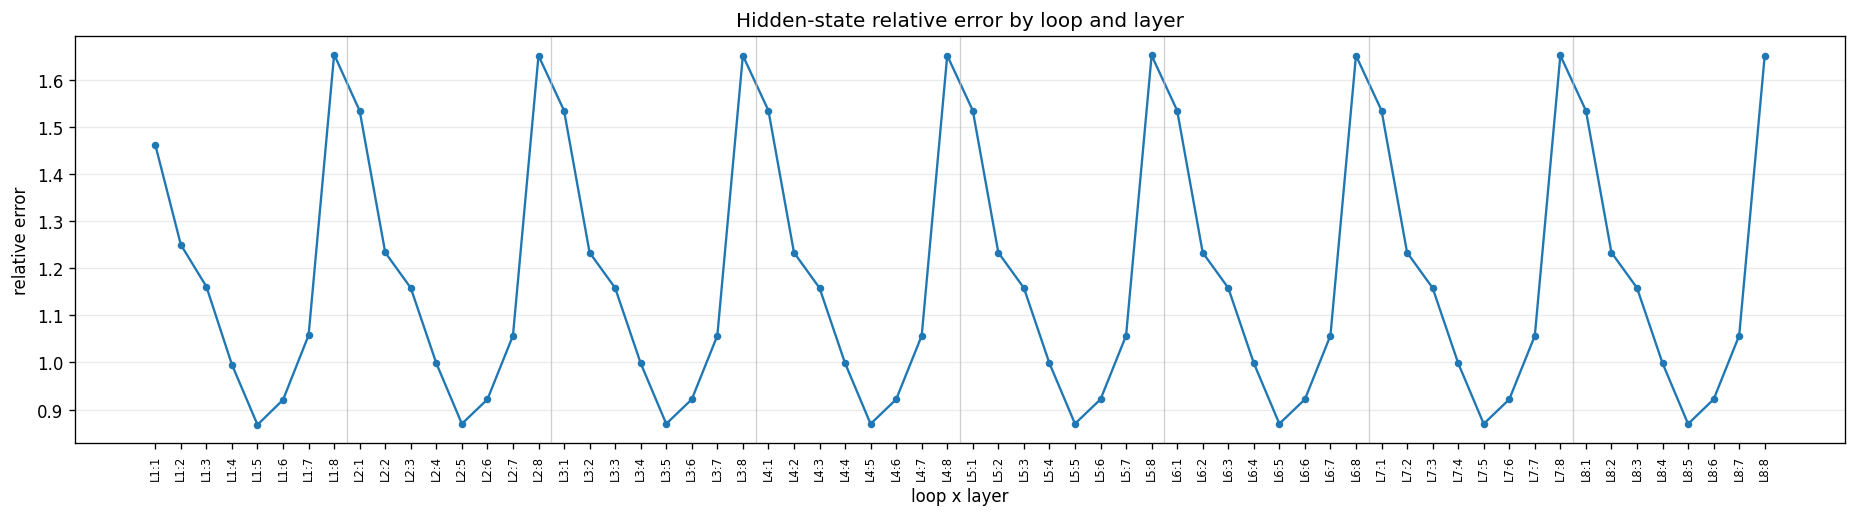

 loop  layer  call  x  relative_error
    1      1     1  1        1.461979
    1      2     2  2        1.249938
    1      3     3  3        1.160939
    1      4     4  4        0.995258
    1      5     5  5        0.867616
    1      6     6  6        0.920671
    1      7     7  7        1.057666
    1      8     8  8        1.653886
    2      1     1  9        1.534297
    2      2     2 10        1.233579
    2      3     3 11        1.158198
    2      4     4 12        0.998308
    2      5     5 13        0.869700
    2      6     6 14        0.921560
    2      7     7 15        1.056923
    2      8     8 16        1.651623
    3      1     1 17        1.534840
    3      2     2 18        1.233302
    3      3     3 19        1.158208
    3      4     4 20        0.998303
    3      5     5 21        0.869613
    3      6     6 22        0.921649
    3      7     7 23        1.056879
    3      8     8 24        1.651717
    4      1     1 25        1.534883
    4      2

In [ ]:
hidden_error_rows = []
for item in trace:
    for call_idx, err in enumerate(item.get("hidden_errors", []), start=1):
        hidden_error_rows.append(
            {
                "loop": int(item["loop"]),
                "layer": int(err["layer"]),
                "call": call_idx,
                "x": (int(item["loop"]) - 1) * len(hidden_trace_layers(train_state.model)) + int(err["layer"]),
                "relative_error": float(err["relative_error"]),
            }
        )

if not hidden_error_rows:
    raise ValueError("No hidden_state relative errors were collected")

hidden_error_x = np.array([row["x"] for row in hidden_error_rows])
hidden_error_y = np.array([row["relative_error"] for row in hidden_error_rows])
hidden_error_labels = [f"L{row['loop']}:{row['layer']}" for row in hidden_error_rows]

fig, ax = plt.subplots(figsize=(max(12.0, 0.24 * len(hidden_error_rows)), 4.2), constrained_layout=True)
ax.plot(hidden_error_x, hidden_error_y, marker="o", linewidth=1.4, markersize=3.5, color="#1F77B4")
for boundary in range(len(hidden_trace_layers(train_state.model)), len(hidden_error_rows), len(hidden_trace_layers(train_state.model))):
    ax.axvline(boundary + 0.5, color="#BBBBBB", linewidth=0.8, alpha=0.7)
ax.set_title("Hidden-state relative error by loop and layer")
ax.set_xlabel("loop x layer")
ax.set_ylabel("relative error")
ax.set_xticks(hidden_error_x)
ax.set_xticklabels(hidden_error_labels, rotation=90, fontsize=7)
ax.grid(True, axis="y", alpha=0.25)
plt.show()

try:
    import pandas as pd
    hidden_error_summary = pd.DataFrame(hidden_error_rows)
    if "display" in globals():
        display(hidden_error_summary)
    else:
        print(hidden_error_summary.to_string(index=False))
except ImportError:
    hidden_error_summary = hidden_error_rows
    for row in hidden_error_rows:
        print(row)


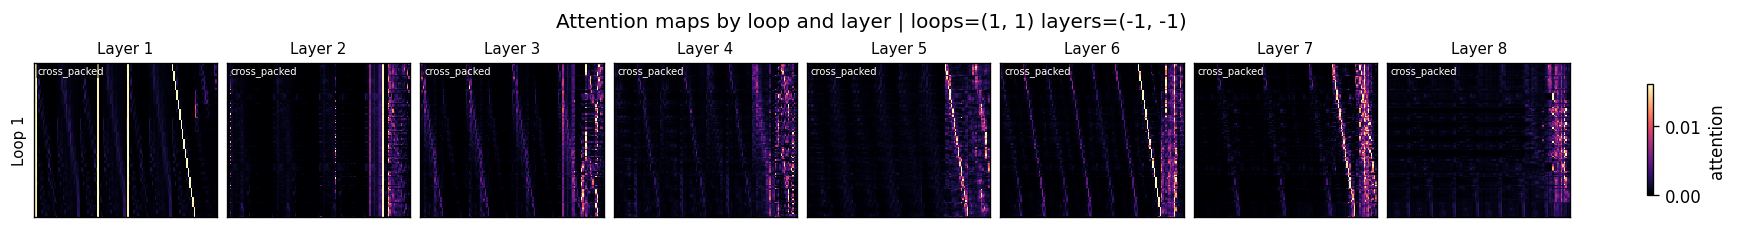

In [ ]:
def downsample_attention_for_display(attn, max_size=128):
    attn = np.asarray(attn, dtype=np.float32)
    h, w = attn.shape
    if h <= max_size and w <= max_size:
        return attn
    row_edges = np.linspace(0, h, min(max_size, h) + 1, dtype=int)
    col_edges = np.linspace(0, w, min(max_size, w) + 1, dtype=int)
    out = np.zeros((len(row_edges) - 1, len(col_edges) - 1), dtype=np.float32)
    for r in range(len(row_edges) - 1):
        r0, r1 = row_edges[r], row_edges[r + 1]
        for c in range(len(col_edges) - 1):
            c0, c1 = col_edges[c], col_edges[c + 1]
            out[r, c] = float(np.nanmean(attn[r0:r1, c0:c1]))
    return out


def resolve_attention_display_range(values, display_range, name):
    values = sorted(values)
    if tuple(display_range) == (-1, -1):
        return values
    if len(display_range) != 2:
        raise ValueError(f"{name} must be a pair like (-1, -1) or (start, end)")
    start, end = (int(display_range[0]), int(display_range[1]))
    if start == -1 and end == -1:
        return values
    if start < 1 or end < start:
        raise ValueError(f"{name} must be (-1, -1) or an inclusive 1-based range with start <= end")
    selected = [value for value in values if start <= value <= end]
    if not selected:
        raise ValueError(f"{name}={display_range} selected no available values from {values}")
    return selected


attention_map_rows = []
for item in trace:
    for call_idx, attn in enumerate(item.get("attention_maps", []), start=1):
        attention_map_rows.append(
            {
                "loop": int(item["loop"]),
                "layer": int(attn["layer"]),
                "call": call_idx,
                "attention_type": attn["attention_type"],
                "attention_map": attn["attention_map"],
            }
        )

if not attention_map_rows:
    raise ValueError("No attention maps were collected")

num_layers = len(hidden_trace_layers(train_state.model))
available_loops = sorted({row["loop"] for row in attention_map_rows})
available_layers = list(range(1, num_layers + 1))
loops = resolve_attention_display_range(available_loops, ATTENTION_LOOP_RANGE, "ATTENTION_LOOP_RANGE")
layers = resolve_attention_display_range(available_layers, ATTENTION_LAYER_RANGE, "ATTENTION_LAYER_RANGE")

attention_by_loop_layer = {}
for row in attention_map_rows:
    attention_by_loop_layer.setdefault((row["loop"], row["layer"]), row)

visible_attention_rows = [
    row for row in attention_map_rows
    if row["loop"] in loops and row["layer"] in layers
]
plot_maps = [downsample_attention_for_display(row["attention_map"]) for row in visible_attention_rows]
vmax = float(np.nanpercentile(np.concatenate([m.ravel() for m in plot_maps]), 99.5))
vmax = max(vmax, 1e-8)

fig, axes = plt.subplots(
    len(loops),
    len(layers),
    figsize=(1.8 * len(layers), 1.8 * len(loops)),
    squeeze=False,
    constrained_layout=True,
)
last_image = None
for r, loop in enumerate(loops):
    for c, layer in enumerate(layers):
        ax = axes[r, c]
        row = attention_by_loop_layer.get((loop, layer))
        if row is None:
            ax.axis("off")
            continue
        attn = downsample_attention_for_display(row["attention_map"])
        last_image = ax.imshow(attn, cmap="magma", vmin=0.0, vmax=vmax, interpolation="nearest", aspect="auto")
        ax.set_xticks([])
        ax.set_yticks([])
        if r == 0:
            ax.set_title(f"Layer {layer}", fontsize=9)
        if c == 0:
            ax.set_ylabel(f"Loop {loop}", fontsize=9)
        ax.text(
            0.02,
            0.98,
            row["attention_type"],
            transform=ax.transAxes,
            va="top",
            ha="left",
            fontsize=6,
            color="white",
            bbox={"facecolor": "black", "alpha": 0.45, "pad": 1, "edgecolor": "none"},
        )

fig.suptitle(
    f"Attention maps by loop and layer | loops={ATTENTION_LOOP_RANGE} layers={ATTENTION_LAYER_RANGE}",
    fontsize=12,
)
if last_image is not None:
    fig.colorbar(last_image, ax=axes, shrink=0.72, label="attention")
plt.show()

try:
    import pandas as pd
    attention_map_summary = pd.DataFrame(
        [
            {
                "loop": row["loop"],
                "layer": row["layer"],
                "call": row["call"],
                "attention_type": row["attention_type"],
                "shape": tuple(row["attention_map"].shape),
            }
            for row in attention_map_rows
        ]
    )
    if "display" in globals():
        display(attention_map_summary)
    # else:
    #     # print(attention_map_summary.to_string(index=False))
except ImportError:
    attention_map_summary = attention_map_rows
    for row in attention_map_rows:
        print({k: v for k, v in row.items() if k != "attention_map"}, "shape=", row["attention_map"].shape)


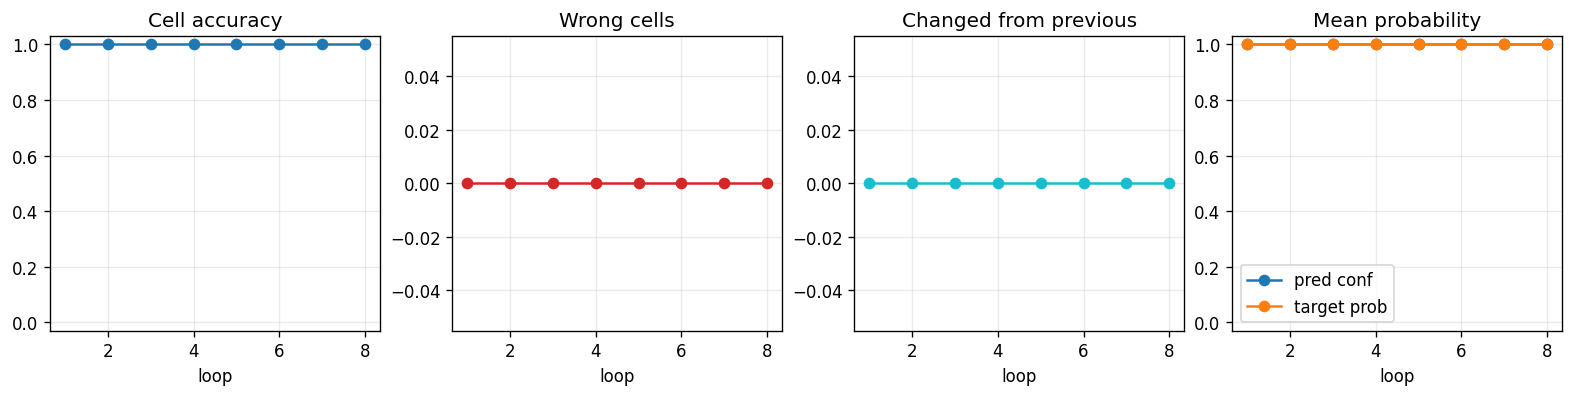

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(13, 3.2), constrained_layout=True)
axes[0].plot(summary["loop"], summary["cell_accuracy"], marker="o")
axes[0].set_title("Cell accuracy")
axes[0].set_xlabel("loop")
axes[0].set_ylim(-0.03, 1.03)
axes[0].grid(True, alpha=0.25)

axes[1].plot(summary["loop"], summary["wrong_cells"], marker="o", color="#D62728")
axes[1].set_title("Wrong cells")
axes[1].set_xlabel("loop")
axes[1].grid(True, alpha=0.25)

axes[2].plot(summary["loop"], summary["changed_from_prev"], marker="o", color="#17BECF")
axes[2].set_title("Changed from previous")
axes[2].set_xlabel("loop")
axes[2].grid(True, alpha=0.25)

axes[3].plot(summary["loop"], summary["mean_confidence"], marker="o", label="pred conf")
axes[3].plot(summary["loop"], summary["mean_true_prob"], marker="o", label="target prob")
axes[3].set_title("Mean probability")
axes[3].set_xlabel("loop")
axes[3].set_ylim(-0.03, 1.03)
axes[3].legend()
axes[3].grid(True, alpha=0.25)
plt.show()

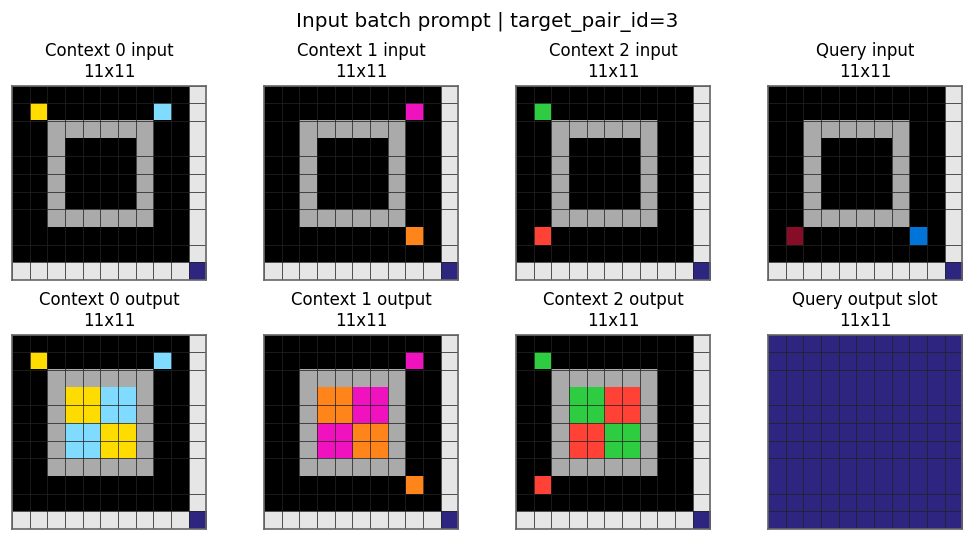

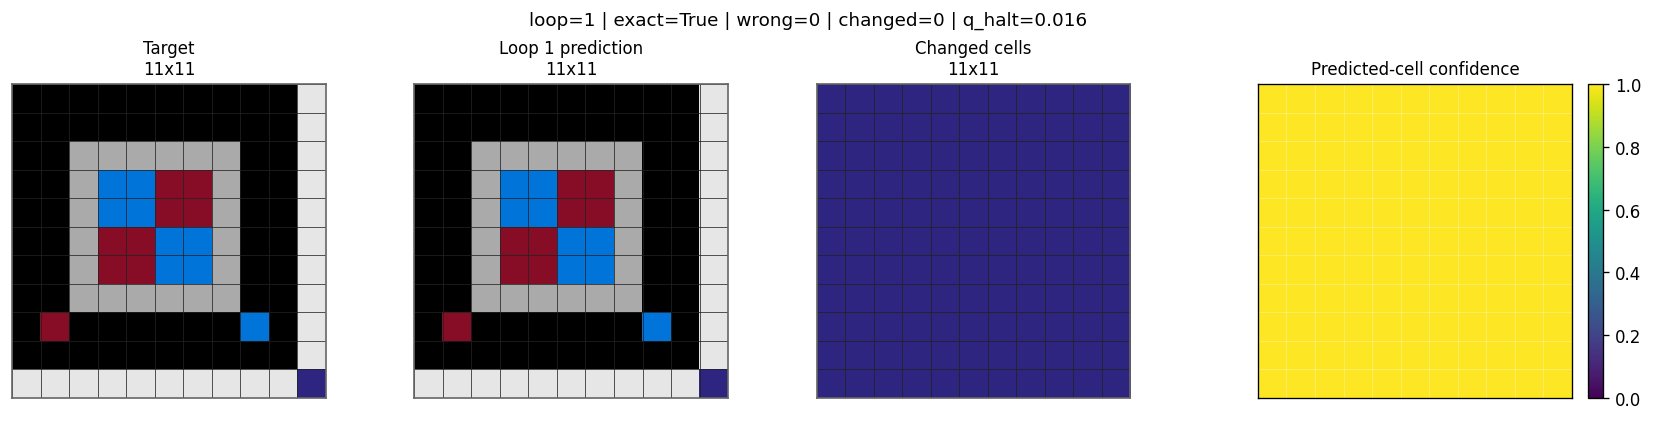

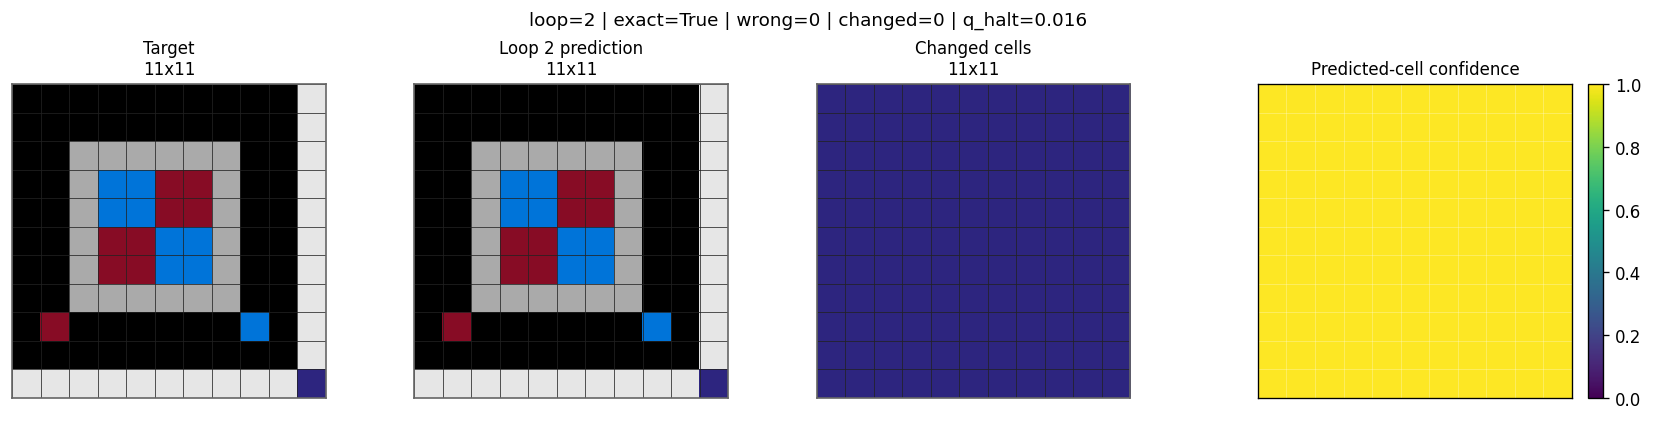

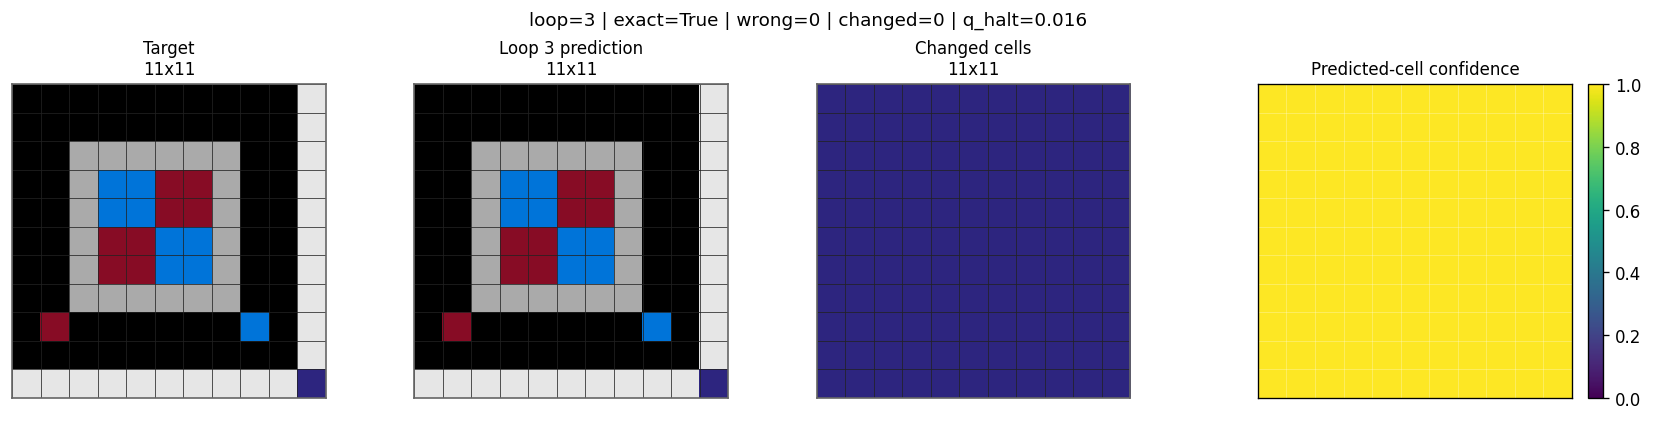

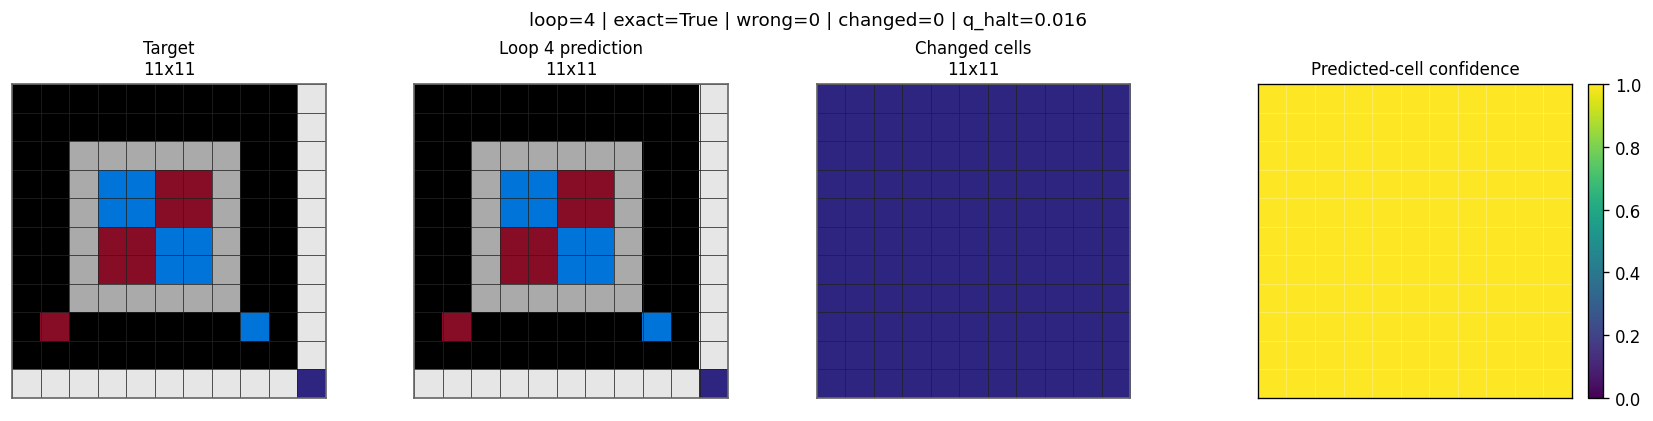

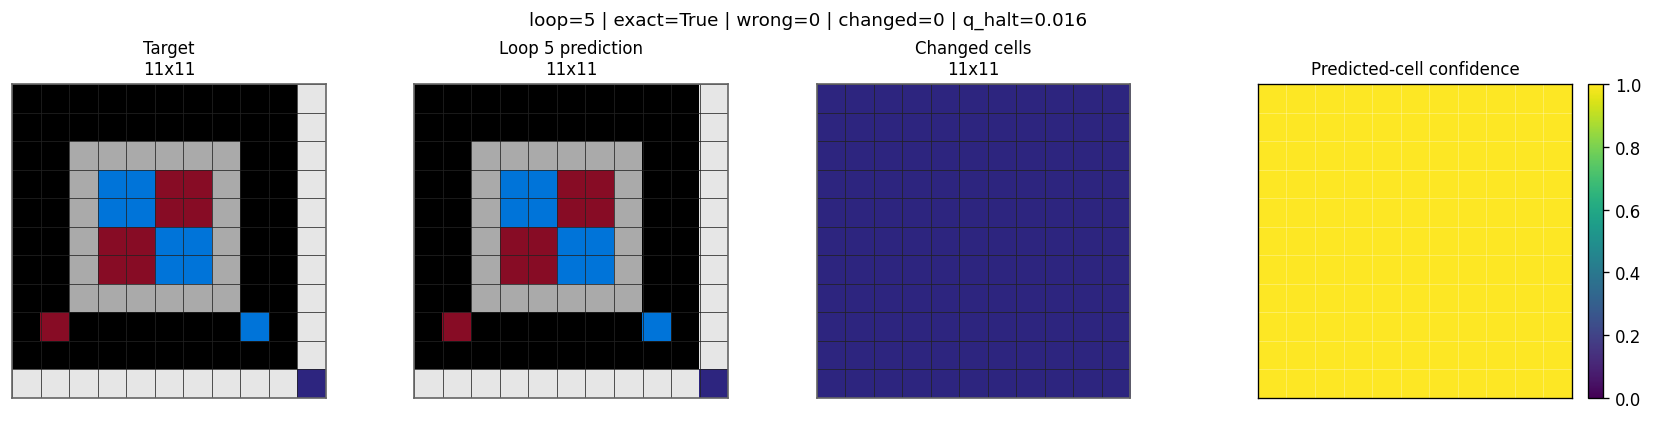

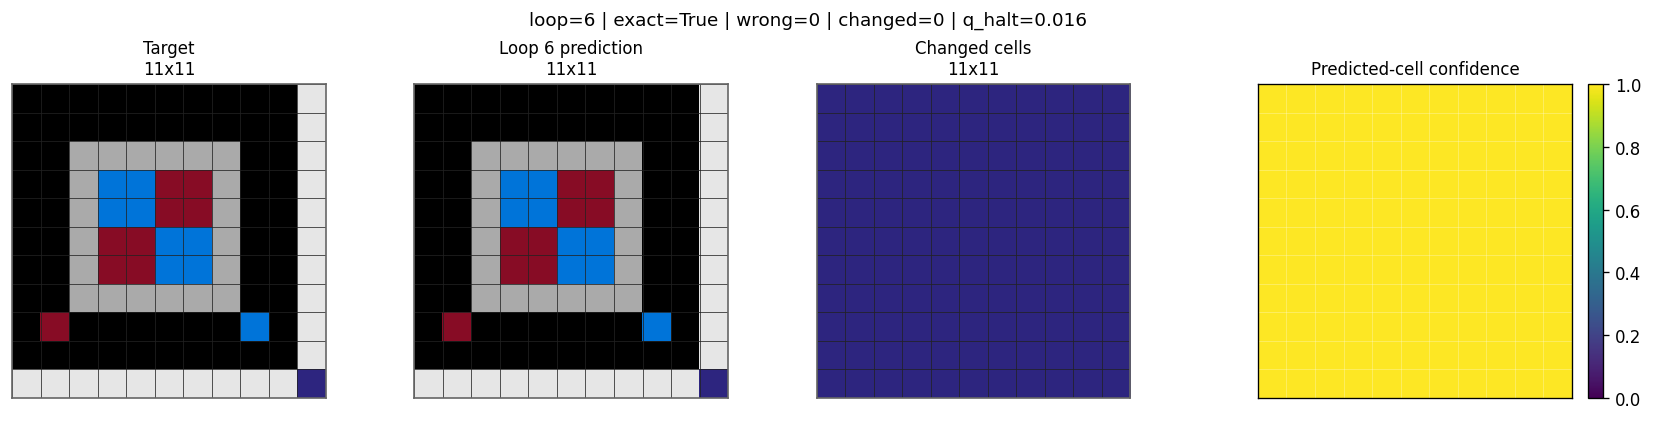

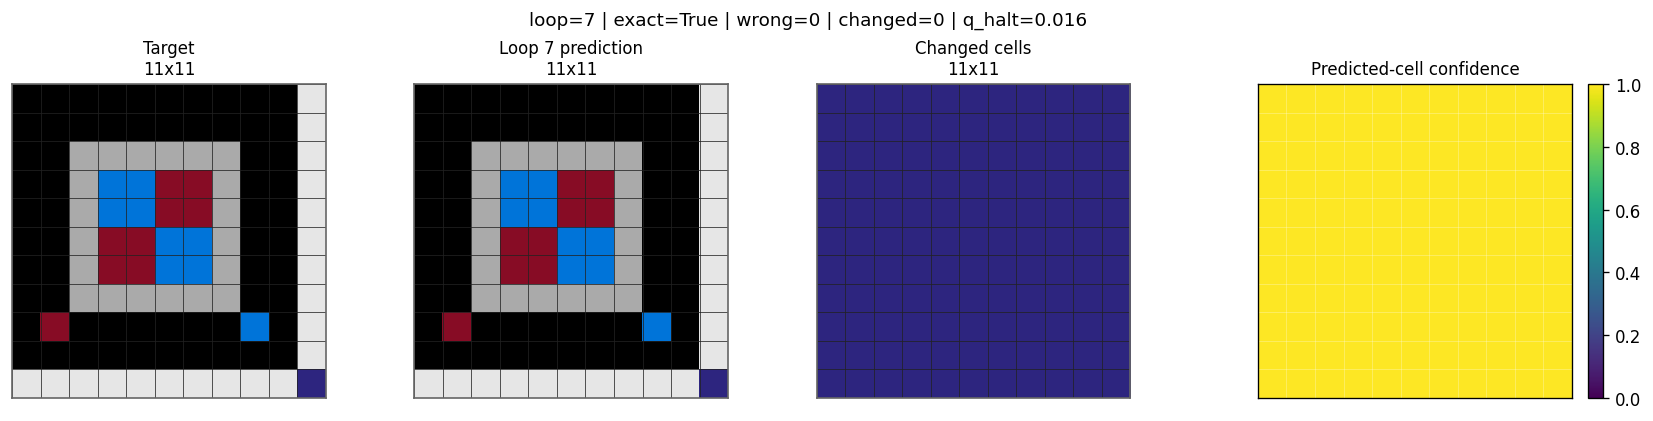

In [ ]:
prompt_cols = len(batch_prompt_pairs)
fig, axes = plt.subplots(2, prompt_cols, figsize=(max(8.0, 2.1 * prompt_cols), 4.4), squeeze=False, constrained_layout=True)
context_idx = 0
for col, pair in enumerate(batch_prompt_pairs):
    if pair["is_query"]:
        title_prefix = "Query"
        output_title = "Query output slot"
    else:
        title_prefix = f"Context {context_idx}"
        output_title = f"Context {context_idx} output"
        context_idx += 1
    render_grid(axes[0, col], pair["input"], f"{title_prefix} input")
    render_grid(axes[1, col], pair["output"], output_title)
fig.suptitle(f"Input batch prompt | target_pair_id={batch_target_pair_id}", fontsize=12)
plt.show()

show_loops = [loop for loop in LOOPS_TO_SHOW if 1 <= loop <= len(decoded_trace)]
for loop in show_loops:
    item = decoded_trace[loop - 1]
    fig, axes = plt.subplots(1, 4, figsize=(14, 3.4), constrained_layout=True)
    render_grid(axes[0], target_grid, "Target")
    render_grid(
        axes[1],
        item["pred_grid"],
        f"Loop {loop} prediction",
        wrong_mask=item["wrong_mask"],
        changed_mask=item["changed_mask"],
    )
    render_grid(axes[2], item["changed_mask"].astype(np.uint8), "Changed cells")
    im = render_confidence(axes[3], item["conf_grid"], "Predicted-cell confidence")
    fig.colorbar(im, ax=axes[3], fraction=0.046, pad=0.04)
    fig.suptitle(
        f"loop={loop} | exact={not item['wrong_mask'].any()} | wrong={int(item['wrong_mask'].sum())} | "
        f"changed={int(item['changed_mask'].sum())} | q_halt={float(item['q_halt'][0]):.3f}",
        fontsize=11,
    )
    plt.show()

In [ ]:
wrong_final = decoded_trace[-1]["wrong_mask"]
if wrong_final.any():
    print("Final wrong cells: row, col, target, pred, confidence, target_prob")
    final = decoded_trace[-1]
    for r, c in zip(*np.where(wrong_final)):
        print(
            f"({r:2d}, {c:2d}) target={int(target_grid[r, c])} pred={int(final['pred_grid'][r, c])} "
            f"conf={float(final['conf_grid'][r, c]):.3f} target_prob={float(final['true_prob_grid'][r, c]):.3f}"
        )
else:
    print("Final prediction is exact.")

Final prediction is exact.
